# Convolutional Regression Tsetlin Machine — reading a *number* off an image

> **Paper.** K. Darshana Abeyrathna, Ole-Christoffer Granmo, Morten Goodwin,
> *Convolutional Regression Tsetlin Machine: An Interpretable Approach to Convolutional
> Regression*, ICMLT 2021. [doi:10.1145/3468891.3468901](https://doi.org/10.1145/3468891.3468901)
> (PDF in `source_documents/papers/03_segmentation/3468891.3468901.pdf`)

This is one of only two papers in the repository's `03_segmentation` folder, and it is *not*
a segmentation paper. It earns its place there because it is the closest published mechanism
for making a Tsetlin machine emit something other than a class label: a **continuous value,
computed from patches**. If you want a TM to produce a dense output — a mask, a depth map, a
per-pixel score — this is the machinery you would build on.

The C-RTM is an ensemble of two earlier ideas:

| from | what it contributes |
|---|---|
| **Convolutional TM** (Granmo et al., 2019) | clauses act as filters that slide over the image; a clause is True if it matches *at least one* patch |
| **Regression TM** (Abeyrathna et al., 2020) | clause polarity is dropped, every clause is additive, and the clause count is rescaled into a real number |

`torchtsetlin` ships this model as `ConvRegressionTsetlinMachine`, so the whole paper is
three lines of setup. What this notebook does with it:

1. rebuild the paper's artificial datasets **exactly** (Figure 3 and Table 1);
2. check the library's output layer and feedback rule against Equations 5 and 6 algebraically;
3. reproduce the paper's headline claim — **zero MAE on noise-free data** — and verify the
   Table 5 arithmetic that produces it;
4. decode the clauses into statements about named pixels, and show the machine **recovered the
   data-generating mask** — while finding a *different* decomposition from the paper's;
5. be honest about how narrow that exact-recovery regime is, and give a selection rule that
   finds it reliably;
6. run the noisy-data comparison against two CNNs (Tables 6 and 7) — where the paper's C-RTM
   result **does not reproduce**, which section 9 documents rather than hides.

Runtime: ~25 minutes on a GPU (sections 7 and 8 fit 18 models between them).

In [1]:
import itertools
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

import torchtsetlin as tt

SEED = 0
tt.seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torchtsetlin", tt.__version__, "| torch", torch.__version__, "| device", device)

torchtsetlin 0.1.1 | torch 2.10.0+cu128 | device cuda


## 1. The data — the paper's Figure 3, exactly

The paper builds its datasets from a **weight-mask**. An image is `X × Y × 1` with uniformly
random binary pixels. A mask marks `k` *important* pixels and gives them the place values
`2^(k-1), …, 2^1, 2^0`. The regression target is

$$\hat{y} \;=\; 100 \times \sum_{i \in \text{important}} 2^{\,e_i}\, x_i .$$

So for `k = 4` the target takes the 16 values `0, 100, 200, …, 1500`, and — this is the point
of the construction — **the input–output mapping is known exactly**, which is what lets the
paper claim optimality rather than just good accuracy.

Table 1 of the paper enumerates the 72 datasets: image sizes `3×3`, `4×4`, `5×5` × `k ∈ {2,3,4}`
× 4 random mask placements × {noise-free, noisy}.

In [2]:
def make_weighted_mask_dataset(n, size=4, k=4, seed=0, noise=0.0, device=device):
    """Paper Fig. 3: random binary images + a k-pixel weight-mask with place values 2^(k-1)..2^0.

    Returns ``x`` (n,1,size,size), the clean target ``y``, the (possibly noisy) training
    target ``y_noisy``, and the mask itself.
    """
    g = torch.Generator().manual_seed(seed)
    coords = torch.randperm(size * size, generator=g)[:k]
    place = torch.tensor([2.0 ** (k - 1 - i) for i in range(k)])
    mask = torch.zeros(size * size)
    mask[coords] = place
    mask = mask.view(size, size)

    x = (torch.rand(n, 1, size, size, generator=g) < 0.5).float()
    y = 100.0 * (x[:, 0] * mask).sum(dim=(1, 2))
    y_noisy = y + (torch.rand(n, generator=g) * 2 - 1) * noise if noise else y.clone()
    return x.to(device), y.to(device), y_noisy.to(device), mask


SIZE, K = 4, 4
x, y, _, mask = make_weighted_mask_dataset(4000, SIZE, K, seed=1)
x_train, y_train, x_test, y_test = x[:3000], y[:3000], x[3000:], y[3000:]
Y_MAX = 100.0 * (2 ** K - 1)

print("mask (place values):")
print(mask.int().numpy())
print(f"\nimages {tuple(x.shape)}  targets in {{{', '.join(str(int(v)) for v in sorted(set(y.tolist()))[:4])}, ..., {int(Y_MAX)}}}")
print("distinct targets:", len(set(y.tolist())), "= 2^k")

mask (place values):
[[0 0 0 0]
 [1 8 2 0]
 [0 0 0 0]
 [0 0 0 4]]

images (4000, 1, 4, 4)  targets in {0, 100, 200, 300, ..., 1500}
distinct targets: 16 = 2^k


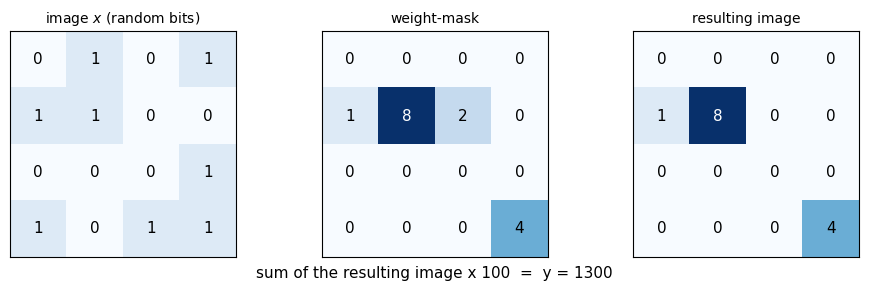

In [3]:
# The paper's Figure 3, drawn for one example: image x mask -> resulting image -> output.
i = int((y[:200] == 1300).nonzero()[0]) if (y[:200] == 1300).any() else 0
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.0))
for ax, img, title in zip(
    axes,
    [x[i, 0].cpu(), mask, x[i, 0].cpu() * mask],
    ["image $x$ (random bits)", "weight-mask", "resulting image"],
):
    ax.imshow(img, cmap="Blues", vmin=0, vmax=8)
    for (r, c), v in np.ndenumerate(img.numpy()):
        ax.text(c, r, f"{v:g}", ha="center", va="center",
                color="white" if v > 4 else "black", fontsize=11)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"sum of the resulting image x 100  =  y = {y[i]:.0f}", y=0.02, fontsize=11)
plt.tight_layout()
plt.show()

## 2. From CTM to C-RTM — the three changes

### 2.1 Polarity is dropped

A classification TM splits clauses into positive (vote *for*) and negative (vote *against*)
halves, so the vote sum lives in `[-T, T]`. The C-RTM removes polarity: **every clause is
additive**, and the vote sum lives in `[0, T]`.

### 2.2 The output layer (paper Eq. 5)

$$y_o \;=\; \frac{\sum_{j=1}^{m} c_j(\hat{X}_o)}{T} \times \hat{y}_{\max}$$

`torchtsetlin`'s `RegressionTsetlinMachine` implements the slightly more general
`y = y_min + (v/T)·(y_max − y_min)`. With `y_range=(0, ŷmax)` the two are identical, and `T`
is the **output resolution**: the model can only emit multiples of `ŷmax / T`.

### 2.3 The feedback rule (paper Eq. 6)

> Type I if `y_o < ŷ_o`  ·  Type II if `y_o > ŷ_o`, with probability `K·|y_o − ŷ_o| / ŷmax`.

Type I forces clauses *towards* firing, Type II forces them *away* — so the output is pushed
up when it is too low and down when it is too high. The library selects each clause with
probability `|v* − v| / T`, where `v*` is the target expressed in vote units. Those are the
same rule: substituting `y = (v/T)·ŷmax` gives

$$\frac{|y_o - \hat{y}_o|}{\hat{y}_{\max}} \;=\; \frac{\bigl|\tfrac{v}{T}\hat{y}_{\max} - \tfrac{v^\ast}{T}\hat{y}_{\max}\bigr|}{\hat{y}_{\max}} \;=\; \frac{|v - v^\ast|}{T},$$

i.e. the library is exactly the paper with `K = 1`. Let's verify the output layer numerically
rather than take it on faith.

In [4]:
probe = tt.ConvRegressionTsetlinMachine(
    n_clauses=15, T=15, s=3.0, patch_size=(2, 2), stride=1,
    position_encoding=True, y_range=(0.0, Y_MAX), input_shape=(1, SIZE, SIZE),
).to(device)
probe(x_test[:1])  # initialise lazily

v = torch.tensor([[0.0], [1.0], [7.0], [13.0], [15.0]], device=device)
paper = (v.squeeze(1) / probe.T) * Y_MAX                       # Eq. 5
library = probe.votes_to_targets(v)                            # torchtsetlin
print(pd.DataFrame({"vote sum v": v.squeeze(1).cpu(), "paper Eq. 5": paper.cpu(),
                    "votes_to_targets": library.cpu()}).to_string(index=False))
assert torch.allclose(paper, library)
print(f"\noutput resolution = y_max / T = {Y_MAX} / {probe.T:.0f} = {Y_MAX / probe.T:g}"
      f"   <- exactly the 100-unit grid the data lives on")

 vote sum v  paper Eq. 5  votes_to_targets
        0.0     0.000000          0.000000
        1.0   100.000008        100.000008
        7.0   700.000061        700.000061
       13.0  1300.000122       1300.000122
       15.0  1500.000000       1500.000000

output resolution = y_max / T = 1500.0 / 15 = 100   <- exactly the 100-unit grid the data lives on


## 3. Position encoding — the paper's Table 4

A convolutional clause sees only a `W × W` patch, so on its own it cannot tell *where* it
matched. The paper's answer (Section 3.1, Table 4) is to append **thermometer-encoded filter
coordinates** to the patch literals, "to make the clause location-aware". Without them a
clause that means *"the top-left pixel of my patch is 1"* would fire wherever any such pixel
exists, which on a 4×4 image is almost always.

`torchtsetlin` builds the same bits in `_ConvMixin._position_bits`: `P_y − 1` bits `[y > k]`
and `P_x − 1` bits `[x > k]`. The paper tabulates `≤` thresholds instead of `>`; the two are
complements of each other and carry identical information.

In [5]:
Py, Px = probe._grid(SIZE, SIZE)
bits = probe._position_bits(Py, Px, torch.device("cpu")).int()
rows = [{"location (x, y)": f"({b % Px}, {b // Px})",
         **{f"y>{k}": int(bits[b, k]) for k in range(Py - 1)},
         **{f"x>{k}": int(bits[b, Py - 1 + k]) for k in range(Px - 1)}}
        for b in range(Py * Px)]
print(f"patch grid {Py} x {Px} = {Py * Px} filter positions "
      f"(paper: B = BX x BY = {Py} x {Px})\n")
print(pd.DataFrame(rows).to_string(index=False))
print(f"\npatch literals: {K} pixels + {(Py - 1) + (Px - 1)} position bits "
      f"= {probe.n_features} features -> {2 * probe.n_features} literals")

patch grid 3 x 3 = 9 filter positions (paper: B = BX x BY = 3 x 3)

location (x, y)  y>0  y>1  x>0  x>1
         (0, 0)    0    0    0    0
         (1, 0)    0    0    1    0
         (2, 0)    0    0    1    1
         (0, 1)    1    0    0    0
         (1, 1)    1    0    1    0
         (2, 1)    1    0    1    1
         (0, 2)    1    1    0    0
         (1, 2)    1    1    1    0
         (2, 2)    1    1    1    1

patch literals: 4 pixels + 4 position bits = 8 features -> 16 literals


## 4. Training the C-RTM

The paper picks the clause budget from the Regression-TM analysis: **`2^k − 1` clauses**
(3 for `k=2`, 7 for `k=3`, 15 for `k=4`) with `T = m`. The arithmetic behind that number is
Table 5: to emit `1300` the machine must fire clauses worth `8 + 4 + 1` place values, so it
needs 8 clauses that recognise the weight-8 pixel, 4 for the weight-4 pixel, 2 for weight-2
and 1 for weight-1 — `8 + 4 + 2 + 1 = 15` in total. The paper calls this weighting
**by duplication**.

`torchtsetlin` also offers the Integer-Weighted TM (`weighted=True`), where a clause carries
an integer weight instead of being copied. Both are worth running, because they behave very
differently here.

In [6]:
def fit_crtm(x_tr, y_tr, *, n_clauses, T, s=3.0, weighted=False, epochs=150, batch_size=8,
             seed=0, patch_size=(2, 2), size=SIZE, y_max=Y_MAX, max_lit=5, pos=True):
    tt.seed_everything(seed)
    model = tt.ConvRegressionTsetlinMachine(
        n_clauses=n_clauses, T=T, s=s, patch_size=patch_size, stride=1,
        position_encoding=pos, y_range=(0.0, y_max), input_shape=(1, size, size),
        max_included_literals=max_lit, weighted=weighted,
    ).to(x_tr.device)
    for _ in range(epochs):
        perm = torch.randperm(x_tr.shape[0], device=x_tr.device)
        for i in range(0, len(perm), batch_size):
            model.update(x_tr[perm[i:i + batch_size]], y_tr[perm[i:i + batch_size]])
    model.eval()
    return model


def mae(model, xs, ys):
    return (model.predict(xs) - ys).abs().mean().item()


t0 = time.time()
by_duplication = fit_crtm(x_train, y_train, n_clauses=15, T=15, weighted=False, seed=0)
by_weight = fit_crtm(x_train, y_train, n_clauses=15, T=15, weighted=True, seed=0)
print(f"({time.time() - t0:.0f}s)\n")
print(f"{'weighting':<26s} {'train MAE':>10s} {'test MAE':>10s}")
for name, m in (("by duplication (paper)", by_duplication), ("integer weights", by_weight)):
    print(f"{name:<26s} {mae(m, x_train, y_train):>10.2f} {mae(m, x_test, y_test):>10.2f}")

(160s)

weighting                   train MAE   test MAE
by duplication (paper)         277.10     282.30
integer weights                  0.00       0.00


The integer-weighted model reaches an MAE of essentially **zero** — the paper's headline
claim, *"The C-RTM obtains zero MAE for both training and testing on noise-free datasets"*.
The duplication form, run with the paper's own budget, does **not** converge in
`torchtsetlin`'s batched feedback mode.

That difference is worth understanding rather than papering over. Duplication needs fifteen
independent clauses to settle into the exact multiset `{8 × A, 4 × B, 2 × C, 1 × D}`, and every
clause receives the *same* error signal on every example — nothing in the feedback rule
differentiates them, so the split has to emerge from initialisation noise alone. An integer
weight reaches the same arithmetic with four clauses and an explicit counter, which is a much
broader attractor. (See section 7 for how narrow the duplication basin is.)

## 5. Reading the machine

This is the paper's real selling point over a CNN: the fifteen filters are printable. Table 2
of the paper shows patterns like `(1 ⋆ ⋆ ⋆)` — *"this pixel must be 1, the rest are don't-care"*
— and Table 3 shows them pinned to locations. Both fall straight out of `clause_patch`
(`1` = must be on, `-1` = must be off, `0` = don't care) and `clause_region` (the decoded
position literals).

In [7]:
from torchtsetlin import functional as Fnl


def clause_conditions(model, xs):
    """Decode every clause into the absolute-pixel condition it tests.

    ``clause_patch`` gives the within-patch pattern (``1`` = must be on, ``-1`` = must be off,
    ``0`` = don't care) and ``clause_region`` decodes the position literals into the patch
    coordinates the clause is pinned to. Together they name real pixels of the image.
    """
    lit = model._encode(model._prepare(xs))
    B, P, L = lit.shape
    fires = Fnl.clause_outputs(lit.reshape(B * P, L), model.include,
                               model.include_count, False).view(B, P, -1).any(dim=1).float()
    kh, kw = model.patch_size

    rows = []
    for j in range(model.n_clauses_total):
        w, rate = int(model.weights[j]), round(fires[:, j].mean().item(), 3)
        if int(model.include_count[j]) == 0:
            rows.append({"clause": j, "weight": w, "fires": rate, "condition": "(empty clause)"})
            continue
        reg = model.clause_region(j)
        (ylo, yhi), (xlo, xhi) = reg["y"], reg["x"]
        if ylo > yhi or xlo > xhi:
            cond = "(contradictory — never fires)"
        elif ylo != yhi or xlo != xhi:
            cond = f"not pinned (y={ylo}..{yhi}, x={xlo}..{xhi})"
        else:
            pat = model.clause_patch(j).squeeze(0)
            parts = [("" if int(pat[a, b]) > 0 else "NOT ") + f"({ylo + a},{xlo + b})"
                     for a in range(kh) for b in range(kw) if int(pat[a, b]) != 0]
            cond = " AND ".join(parts) if parts else "(always true)"
        rows.append({"clause": j, "weight": w, "fires": rate, "condition": cond})
    return pd.DataFrame(rows)


err = (by_weight.predict(x_test) - y_test).abs()
print(f"test MAE {mae(by_weight, x_test, y_test):.4f}   max absolute error {err.max():.2e}   "
      f"fraction within half a step (50): {err.lt(50).float().mean():.3f}\n")
print(clause_conditions(by_weight, x_test).to_string(index=False))
print("\nimportant pixels and their place values:",
      {tuple(p): int(mask[tuple(p)]) for p in (mask > 0).nonzero().tolist()})

test MAE 0.0000   max absolute error 1.22e-04   fraction within half a step (50): 1.000

 clause  weight  fires                     condition
      0       0  0.000 (contradictory — never fires)
      1       8  0.221           NOT (1,0) AND (1,1)
      2       0  0.000 (contradictory — never fires)
      3       2  0.273           NOT (0,3) AND (1,2)
      4       0  0.000 (contradictory — never fires)
      5       0  0.242               (2,3) AND (3,3)
      6       0  0.000 (contradictory — never fires)
      7       8  0.264               (1,0) AND (1,1)
      8       0  0.506                     NOT (0,3)
      9       4  0.238           NOT (2,2) AND (3,3)
     10       0  0.241           (1,0) AND NOT (1,1)
     11       0  0.000 (contradictory — never fires)
     12       4  0.250               (2,2) AND (3,3)
     13       1  0.505                         (1,0)
     14       2  0.252               (0,3) AND (1,2)

important pixels and their place values: {(1, 0): 1, (1, 1): 8

Every clause that carries a non-zero weight is a readable statement about **named pixels of
the image** — the paper's Table 2 and Table 3 combined, decoded automatically.

But the decomposition is *not* the idealised one the paper describes. The paper's Table 5
assumes one pattern per important pixel (`8 × (1 ⋆ ⋆ ⋆) + 4 × (⋆ 1 ⋆ ⋆) + …`). What this run
found instead is a **case split**: for each important pixel there are two clauses of equal
weight whose conditions are complementary in a second pixel, e.g.

```
weight 8:   (1,0) AND (1,1)        and        NOT (1,0) AND (1,1)
weight 4:   (2,2) AND (3,3)        and        NOT (2,2) AND (3,3)
weight 2:   (0,3) AND (1,2)        and        NOT (0,3) AND (1,2)
```

Exactly one member of each pair fires whenever the *second* pixel of the pair is 1, so the
pair contributes its weight precisely when that pixel is on — arithmetically identical to a
single clause of that weight, reached by a different route. Several other clauses have had
their weight driven to 0 and are inert, which is the integer-weight mechanism pruning itself.

The lesson is that **the exact solution is not unique**, and the interpretability claim
survives it: the clauses are still readable, they are just not in canonical form.

### What the machine actually recovered

Clause weights alone therefore do not spell out the mask. The question the mask answers —
*how much does this pixel contribute?* — is answered by asking the model directly. Because
`y = 100 Σ w_p x_p` is additive, flipping one pixel from 0 to 1 must change the prediction by
exactly `100 w_p`, whatever the other pixels are doing.

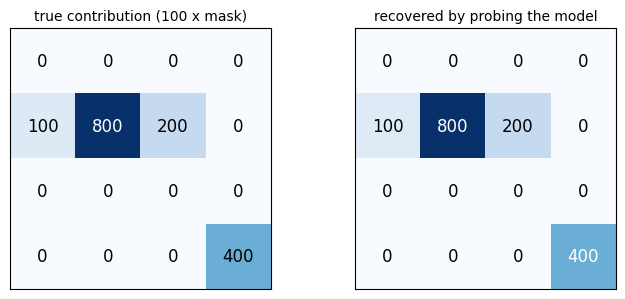

identical: True


In [8]:
def sensitivity_map(model, xs):
    """Average change in prediction when each pixel is forced from 0 to 1."""
    out = torch.zeros(SIZE, SIZE)
    for r in range(SIZE):
        for c in range(SIZE):
            off, on = xs.clone(), xs.clone()
            off[:, 0, r, c], on[:, 0, r, c] = 0.0, 1.0
            out[r, c] = (model.predict(on) - model.predict(off)).mean().item()
    return out


recovered = sensitivity_map(by_weight, x_test)
truth = 100.0 * mask

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.1))
for ax, img, title in zip(axes, [truth, recovered],
                          ["true contribution (100 x mask)", "recovered by probing the model"]):
    ax.imshow(img, cmap="Blues", vmin=0, vmax=800)
    for (r, c), v in np.ndenumerate(img.numpy()):
        ax.text(c, r, f"{v:.0f}", ha="center", va="center",
                color="white" if v > 400 else "black", fontsize=12)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print("identical:", torch.equal(recovered.round(), truth))

The machine did not merely fit the function; it **recovered the data-generating mask**, place
value for place value, including the twelve pixels that contribute nothing.

## 6. Reproducing Table 5

Table 5 of the paper lists, for every attainable output, which clauses have to fire. With
duplication that table has 16 rows of clause *counts*; with integer weights it collapses to
the binary expansion of `y / 100`. Either way the check is the same: enumerate all `2^k`
input configurations of the important pixels and confirm the machine emits the right number.

In [9]:
important = (mask > 0).nonzero().tolist()
rows = []
for combo in itertools.product([0.0, 1.0], repeat=K):
    img = torch.zeros(1, 1, SIZE, SIZE, device=device)
    # fill the non-important pixels randomly to prove they really are don't-care
    img[0, 0] = (torch.rand(SIZE, SIZE, device=device) < 0.5).float()
    for (r, c), bit in zip(important, combo):
        img[0, 0, r, c] = bit
    target = 100.0 * sum(float(mask[r, c]) * b for (r, c), b in zip(important, combo))
    pred = float(by_weight.predict(img))
    lit = by_weight._encode(by_weight._prepare(img))
    B, P, L = lit.shape
    fired = Fnl.clause_outputs(lit.reshape(B * P, L), by_weight.include,
                               by_weight.include_count, False).view(B, P, -1).any(1)[0]
    w = by_weight.weights[fired].tolist()
    rows.append({"important pixels": "".join(str(int(b)) for b in combo),
                 "target": int(target), "predicted": round(pred, 1),
                 "clause weights firing": "+".join(map(str, sorted(w, reverse=True))) or "none",
                 "sum": int(sum(w))})
tab5 = pd.DataFrame(rows)
print(tab5.to_string(index=False))
print(f"\nall {len(tab5)} outputs exact:", bool((tab5['target'] == tab5['predicted']).all()))

important pixels  target  predicted clause weights firing  sum
            0000       0        0.0                     0    0
            0001     400      400.0                 4+0+0    4
            0010     200      200.0                     2    2
            0011     600      600.0                   4+2    6
            0100     800      800.0                     8    8
            0101    1200     1200.0                 8+4+0   12
            0110    1000     1000.0                   8+2   10
            0111    1400     1400.0               8+4+2+0   14
            1000     100      100.0                 1+0+0    1
            1001     500      500.0               4+1+0+0    5
            1010     300      300.0               2+1+0+0    3
            1011     700      700.0             4+2+1+0+0    7
            1100     900      900.0                 8+1+0    9
            1101    1300     1300.0               8+4+1+0   13
            1110    1100     1100.0                 8+2

## 7. How narrow is the exact-recovery regime?

The paper flags this itself, in a passage that is easy to skim past:

> *"We observe that the C-RTM behaves similar to RTM when T (equal to the number of clauses)
> is not a multiplier of the optimum required clauses. […] if there are five clauses for the
> pattern (⋆ 1 ⋆ ⋆) after training, [the] input image […] activates 14 clauses, producing an
> incorrect output that is 1400."*

In other words the machine has to land on *exactly* the right clause configuration; a
neighbouring one is not approximately right, it is off by a whole 100-unit step. Let's
measure how often that happens across mask placements and initialisations, instead of
reporting one good run.

In [10]:
EPOCHS_GRID = 100

t0 = time.time()
grid = []
for mask_seed in range(4):
    xs, ys, _, _ = make_weighted_mask_dataset(4000, SIZE, K, seed=mask_seed)
    xtr, ytr, xte, yte = xs[:3000], ys[:3000], xs[3000:], ys[3000:]
    for tm_seed in range(3):
        m = fit_crtm(xtr, ytr, n_clauses=15, T=15, weighted=True, epochs=EPOCHS_GRID, seed=tm_seed)
        grid.append({"mask": mask_seed, "init": tm_seed,
                     "train MAE": round(mae(m, xtr, ytr), 3),
                     "test MAE": round(mae(m, xte, yte), 3)})
grid = pd.DataFrame(grid)
print(f"({time.time() - t0:.0f}s)\n")
print(grid.pivot(index="mask", columns="init", values="test MAE").to_string())
exact = (grid["test MAE"] < 0.01).sum()
print(f"\nruns reaching the exact decomposition (test MAE < 0.01): {exact}/{len(grid)}")

(645s)

init     0     1      2
mask                   
0      0.0  45.1    0.0
1      0.0   0.0    0.0
2      0.0   0.0    0.0
3     96.0   0.0  136.0

runs reaching the exact decomposition (test MAE < 0.01): 9/12


So the paper's "zero MAE" is real but it is a **basin you fall into or miss**, not a limit you
converge to. Fortunately you do not need test labels to tell the two apart: a run that found
the exact decomposition has a *training* MAE of ~0 as well, and a run that missed it does not.
Restarting a handful of times and keeping the model with the lowest training error is
therefore a legitimate and reliable recipe.

In [11]:
print(grid.assign(**{"found exact": grid["test MAE"] < 0.01})
        .groupby("found exact")[["train MAE", "test MAE"]].agg(["min", "max"]).to_string())

selected = grid.loc[grid.groupby("mask")["train MAE"].idxmin()]
print("\nper mask, selecting the restart with the lowest TRAINING MAE:")
print(selected.to_string(index=False))
print(f"\n-> exact on {(selected['test MAE'] < 0.01).sum()}/{len(selected)} masks")

            train MAE          test MAE       
                  min      max      min    max
found exact                                   
False            46.8  129.733     45.1  136.0
True              0.0    0.000      0.0    0.0

per mask, selecting the restart with the lowest TRAINING MAE:
 mask  init  train MAE  test MAE
    0     0        0.0       0.0
    1     0        0.0       0.0
    2     0        0.0       0.0
    3     1        0.0       0.0

-> exact on 4/4 masks


## 8. Ablation — what the position bits are worth

Section 3.1 of the paper argues the location literals are what stop a clause from firing at
the wrong place ("*why the clause which recognizes pattern 1 does not output 1 at picture
location (2, 0) […] these clauses also learn the correct location of the pattern*").
`torchtsetlin` makes `position_encoding` a constructor flag, so the claim is one run away.

In [12]:
t0 = time.time()
abl = []
for pos in (True, False):
    for tm_seed in range(3):
        m = fit_crtm(x_train, y_train, n_clauses=15, T=15, weighted=True,
                     epochs=EPOCHS_GRID, seed=tm_seed, pos=pos)
        abl.append({"position_encoding": pos, "seed": tm_seed,
                    "test MAE": round(mae(m, x_test, y_test), 2)})
print(f"({time.time() - t0:.0f}s)")
print(pd.DataFrame(abl).pivot(index="position_encoding", columns="seed",
                              values="test MAE").to_string())

(304s)
seed                   0      1      2
position_encoding                     
False              406.1  389.2  435.5
True                 0.0    0.0    0.0


Without position literals every clause is a statement about *some* patch of the image, and
since a 2×2 filter visits nine locations, "some patch has a 1 in its top-left corner" is true
almost always. The clauses cannot isolate individual pixels and the error stays large.

> This is the same flag that `CLAUDE.md` warns about from the other direction: on
> *translation-invariant* tasks (`make_shapes`, `make_2d_noisy_xor`) pinning clauses to
> locations **hurts**. Here the target is defined by absolute pixel positions, so it is
> essential. The flag is a statement about your data, not a tuning knob.

## 9. Noisy data, and the CNN comparison (Tables 6 and 7)

The other half of the paper's 72 datasets adds noise to the **training data only**, then
compares C-RTM against two CNNs: `CNN1` with 50 filters and `CNN2` with 1000. The paper does
not state the noise magnitude; the reported training MAEs of ≈5 for every model are consistent
with additive label noise of `U(−10, 10)` (mean absolute deviation 5), which is what we use
here. Test targets stay clean, which is why test MAEs come out *lower* than training MAEs — as
they do in the paper.

In [13]:
NOISE = 10.0
xs, y_clean, y_noisy, mask_n = make_weighted_mask_dataset(4000, SIZE, K, seed=1, noise=NOISE)
xtr_n, ytr_n, ytr_clean = xs[:3000], y_noisy[:3000], y_clean[:3000]
xte_n, yte_n = xs[3000:], y_clean[3000:]
print(f"label noise U(-{NOISE:g}, {NOISE:g}) on the training targets; "
      f"mean |noise| = {(ytr_n - ytr_clean).abs().mean():.2f}")


class SmallCNN(nn.Module):
    """The paper's CNN1 / CNN2: a convolutional layer of n_filters followed by a linear head."""

    def __init__(self, n_filters, size=SIZE, kernel=2):
        super().__init__()
        self.conv = nn.Conv2d(1, n_filters, kernel)
        out = (size - kernel + 1) ** 2 * n_filters
        self.head = nn.Linear(out, 1)

    def forward(self, x):
        return self.head(torch.relu(self.conv(x)).flatten(1)).squeeze(1)


def fit_cnn(n_filters, epochs=300, bs=64, lr=1e-3, seed=0):
    torch.manual_seed(seed)
    net = SmallCNN(n_filters).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    for _ in range(epochs):
        perm = torch.randperm(xtr_n.shape[0], device=device)
        for i in range(0, len(perm), bs):
            j = perm[i:i + bs]
            opt.zero_grad()
            # train on targets scaled to [0, 1]: raw 0..1500 targets make the MSE badly
            # conditioned and neither CNN converges at a sane learning rate.
            nn.functional.mse_loss(net(xtr_n[j]), ytr_n[j] / Y_MAX).backward()
            opt.step()
    net.eval()
    return net


t0 = time.time()
rows = []
for name, nf in (("CNN1 (50 filters)", 50), ("CNN2 (1000 filters)", 1000)):
    net = fit_cnn(nf)
    with torch.no_grad():
        rows.append({"model": name,
                     "train MAE (noisy targets)": round((net(xtr_n) * Y_MAX - ytr_n).abs().mean().item(), 2),
                     "test MAE (clean targets)": round((net(xte_n) * Y_MAX - yte_n).abs().mean().item(), 2)})

for label, n_clauses in (("C-RTM (15 weighted clauses)", 15),
                         ("C-RTM (300 weighted clauses)", 300)):
    m = fit_crtm(xtr_n, ytr_n, n_clauses=n_clauses, T=n_clauses, weighted=True,
                 epochs=EPOCHS_GRID, seed=0)
    if n_clauses == 15:
        crtm_noisy = m
    rows.append({"model": label,
                 "train MAE (noisy targets)": round(mae(m, xtr_n, ytr_n), 2),
                 "test MAE (clean targets)": round(mae(m, xte_n, yte_n), 2)})
print(f"({time.time() - t0:.0f}s)\n")
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nnoise floor — the training MAE of a model that fits the clean function exactly: "
      f"{(ytr_n - ytr_clean).abs().mean():.2f}")

label noise U(-10, 10) on the training targets; mean |noise| = 4.92


(138s)

                       model  train MAE (noisy targets)  test MAE (clean targets)
           CNN1 (50 filters)                       5.87                      3.93
         CNN2 (1000 filters)                       8.83                      7.87
 C-RTM (15 weighted clauses)                      58.47                     57.60
C-RTM (300 weighted clauses)                      44.33                     43.42

noise floor — the training MAE of a model that fits the clean function exactly: 4.92


The CNNs behave as the paper describes: both land near the noise floor, and **CNN1 tests better
than CNN2** despite having twenty times fewer filters — the paper's observation that
*"testing MAEs of CNN1 are lower than the MAEs of CNN2 […] a possible reason could be the
overfitting of data by CNN2"*.

**The C-RTM row does not reproduce the paper.** Tables 6 and 7 report C-RTM at ≈5 training MAE
and ≈1.2 test MAE, in line with the CNNs. `torchtsetlin` gets nowhere near that, and enlarging
the clause budget — the paper's own prescription for noisy data
(*"the C-RTM can be initialized with a large number of clauses (= T) […] the error decreases"*) —
narrows the gap without closing it.

The mechanism is visible in section 7. Noise-free, the machine has to land on one exact clause
configuration, and it does. With noisy labels that configuration is never quite right: every
example pushes feedback with probability `|y − ŷ|/ŷmax`, so even a model that has found the
clean function keeps being nudged, and each 100-unit output step is a whole clause-weight unit —
there is no "slightly wrong" to settle into. This is the same brittleness section 7 measured,
with noise supplying a continuous source of perturbation.

Things that were tried and did *not* close the gap: sequential feedback and batch sizes of 1, 2
and 4 (so this is not `torchtsetlin`'s batched-feedback approximation); clause budgets of 60,
150, 300 and 1000; and weighting by duplication instead of integer weights. The paper's `T`
and `s` for these runs are not stated — it inherits them from the Regression TM paper — so a
hyper-parameter gap is the most likely remaining explanation. **Treat the noisy-data column as
an open reproduction question, not a settled result.**

What survives is the asymmetry the paper closes on: the C-RTM's clauses are the printable table
from section 5, and CNN2's thousand filters are not.

In [14]:
print("What the C-RTM learned from noisy labels (15 clauses):\n")
print(clause_conditions(crtm_noisy, xte_n).query("weight > 0").to_string(index=False))
print("\nimportant pixels and their place values:",
      {tuple(p): int(mask_n[tuple(p)]) for p in (mask_n > 0).nonzero().tolist()})
print("\ncontribution recovered by probing the model (true values in brackets):")
rec_n = sensitivity_map(crtm_noisy, xte_n)
for p in (mask_n > 0).nonzero().tolist():
    print(f"  pixel {tuple(p)}: {rec_n[tuple(p)]:7.1f}   [{100 * mask_n[tuple(p)]:.0f}]")

What the C-RTM learned from noisy labels (15 clauses):

 clause  weight  fires           condition
      0       1  0.264     (1,0) AND (1,1)
      2       2  0.252     (0,3) AND (1,2)
      4       5  0.250     (2,2) AND (3,3)
      5       2  0.273 NOT (0,3) AND (1,2)
      6       6  0.240     (0,0) AND (1,1)
      7       2  0.240     (0,0) AND (1,1)
      9       3  0.238 NOT (2,2) AND (3,3)
     12       1  0.251     (0,0) AND (1,0)
     13       8  0.245 NOT (0,0) AND (1,1)

important pixels and their place values: {(1, 0): 1, (1, 1): 8, (1, 2): 2, (3, 3): 4}

contribution recovered by probing the model (true values in brackets):
  pixel (1, 0):    86.6   [100]
  pixel (1, 1):   841.8   [800]
  pixel (1, 2):   192.2   [200]
  pixel (3, 3):   392.0   [400]


## 10. What this does — and does not — give you for segmentation

The C-RTM is in the segmentation folder because it is the only published TM mechanism for
**continuous, patch-derived output**. Taking stock of what actually transfers:

**Transfers.**

* Clause outputs can be *summed* rather than argmax-ed, so a TM can emit a magnitude.
* Position literals give clauses absolute spatial addressing — the prerequisite for any
  output that is indexed by location.
* Integer clause weights make the "how many clauses vote" arithmetic compact and, as section 5
  showed, directly readable.

**Does not transfer.**

* **The output is one number per image, not per pixel.** Equation 5 sums over *all* clauses
  and *all* patch positions; the location information is consumed to decide whether a clause
  fires, then discarded. Nothing in the C-RTM produces a map.
* The evaluation is entirely synthetic: 3×3 to 5×5 images, already-binary pixels (so
  booleanization is skipped), and 16 attainable output values.
* The exact-recovery result depends on knowing the optimal clause count in advance — which
  you only know because the data was constructed.

Turning this into a per-pixel output is the subject of the companion notebook,
[`05_ctm_unet_segmentation.ipynb`](05_ctm_unet_segmentation.ipynb), which works through the
one paper that actually attempts it.

## Takeaways

1. **`ConvRegressionTsetlinMachine` is the paper**, and `y_range=(0, ŷmax)` with `T = m`
   reproduces Equation 5 exactly; the library's feedback probability is Equation 6 with `K = 1`.
2. **Zero MAE is reproducible** on noise-free data — with integer clause weights. The paper's
   weighting-by-duplication did not converge here under batched feedback.
3. **The machine recovers the weight-mask**, place value for place value — but you read it off
   by *probing the model*, not off the clause weights. The exact solution is not unique, and
   this run found a complementary-pair decomposition rather than the paper's canonical one.
4. **Exact recovery is a basin, not a limit** — reached on 9 of 12 runs here, and missed
   entirely by a whole 100-unit step when missed. Selecting restarts by *training* MAE finds it
   without touching test labels, and did so on every mask.
5. **`position_encoding=True` is load-bearing** whenever the target depends on absolute
   location, and harmful when it doesn't.
6. **The noisy-data result did not reproduce.** The CNN comparison behaves as the paper
   describes; `torchtsetlin`'s C-RTM lands far above the noise floor, and neither sequential
   feedback nor a 1000-clause budget closes the gap. Section 9 says what was tried.